<a href="https://colab.research.google.com/github/aayurganesh2007-max/Neural_Networks_with_pytorch/blob/main/Pytorchbasics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Some basic tensor operations

In [5]:
import torch
import numpy as np

data_tensor = torch.tensor([1,2,3,4])

zero_tensor = torch.zeros((2,3))
ones_tensor = torch.ones((2,3,3))
rand_tensor = torch.rand(2,3)

np_array = np.array([1,2,3,4])
np_tensor = torch.from_numpy(np_array)

print(data_tensor)
print(zero_tensor)
print(ones_tensor)
print(rand_tensor)
print(np_tensor)


tensor([1, 2, 3, 4])
tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]])
tensor([[0.6487, 0.8431, 0.8500],
        [0.0752, 0.5242, 0.3983]])
tensor([1, 2, 3, 4])


reshaping and slicing

In [17]:
my_torch = torch.arange(10)
print(my_torch)

my_torch = my_torch.reshape(2,5)
print(my_torch)

my_torch = my_torch.reshape(5,-1)
print(my_torch)

my_torch = my_torch.view(2,5)
print(my_torch)

#reshape and viw will update
my_torch2 = torch.arange(12)
my_torch3 = my_torch2.reshape(4,3)
my_torch2[2]= 22
print(my_torch2)
print(my_torch3)

#slicing
print(my_torch[:,1])
print(my_torch[1,2])
print(my_torch[:,1:])



tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])
tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])
tensor([ 0,  1, 22,  3,  4,  5,  6,  7,  8,  9, 10, 11])
tensor([[ 0,  1, 22],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])
tensor([1, 6])
tensor(7)
tensor([[1, 2, 3, 4],
        [6, 7, 8, 9]])


Basic Tensor Math Operation

In [23]:
a = torch.tensor([1,2,3,4])
b = torch.tensor([5,6,7,8])
print(a+b)
print(a.add(b))
print(torch.add(a,b))

print(a-b)
print(torch.sub(a,b))

print(a*b)
print(torch.mul(a,b))

print(a/b)
print(torch.div(a,b))

print(a%b)
print(torch.remainder(a,b))

print(torch.pow(a,b))

a = a+b
a.add_(b)#notice the underscore does a=a+b
print(a)

tensor([ 6,  8, 10, 12])
tensor([ 6,  8, 10, 12])
tensor([ 6,  8, 10, 12])
tensor([-4, -4, -4, -4])
tensor([-4, -4, -4, -4])
tensor([ 5, 12, 21, 32])
tensor([ 5, 12, 21, 32])
tensor([0.2000, 0.3333, 0.4286, 0.5000])
tensor([0.2000, 0.3333, 0.4286, 0.5000])
tensor([1, 2, 3, 4])
tensor([1, 2, 3, 4])
tensor([    1,    64,  2187, 65536])
tensor([11, 14, 17, 20])


Basic Neural Networks


In [7]:
import torch.nn as nn
import torch.nn.functional as F

# Create a model class that inherits nn.Module

class Model(nn.Module):
  # Input_layer (4 features of the flower) ->
  #hidden layer1( number of neurons) -->
  # H2 (n) -->
  #output (3 classes of the flower)

  def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features,h1)
    self.fc2 = nn.Linear(h1,h2)
    self.out = nn.Linear(h2,out_features)

  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

#Pick a random seed for randomisation
torch.manual_seed(41)
#Create an instance of the model
model = Model()

Loading the *data*

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)
#changing the last columns from the strings to ints
my_df["species"]= my_df["species"].replace("setosa",0.0)
my_df["species"]= my_df["species"].replace("versicolor",1.0)
my_df["species"]= my_df["species"].replace("virginica",2.0)




/tmp/ipykernel_11541/3616071068.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df["species"]= my_df["species"].replace("virginica",2.0)


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

Splitting the data and training


Epoch: 0 and loss: 0.011164982803165913
Epoch: 1 and loss: 0.011179785244166851
Epoch: 2 and loss: 0.011395515874028206
Epoch: 3 and loss: 0.011127231642603874
Epoch: 4 and loss: 0.011177527718245983
Epoch: 5 and loss: 0.011235866695642471
Epoch: 6 and loss: 0.01111278124153614
Epoch: 7 and loss: 0.011071352288126945
Epoch: 8 and loss: 0.011136973276734352
Epoch: 9 and loss: 0.011120770126581192
Epoch: 10 and loss: 0.011043688282370567
Epoch: 11 and loss: 0.011028902605175972
Epoch: 12 and loss: 0.011061965487897396
Epoch: 13 and loss: 0.011048926040530205
Epoch: 14 and loss: 0.01099709328263998
Epoch: 15 and loss: 0.010976691730320454
Epoch: 16 and loss: 0.010992509312927723
Epoch: 17 and loss: 0.010986113920807838
Epoch: 18 and loss: 0.010948622599244118
Epoch: 19 and loss: 0.010925746522843838
Epoch: 20 and loss: 0.010929821990430355
Epoch: 21 and loss: 0.010925077833235264
Epoch: 22 and loss: 0.010897396132349968
Epoch: 23 and loss: 0.01087437104433775
Epoch: 24 and loss: 0.0108709

Text(0.5, 0, 'Epoch')

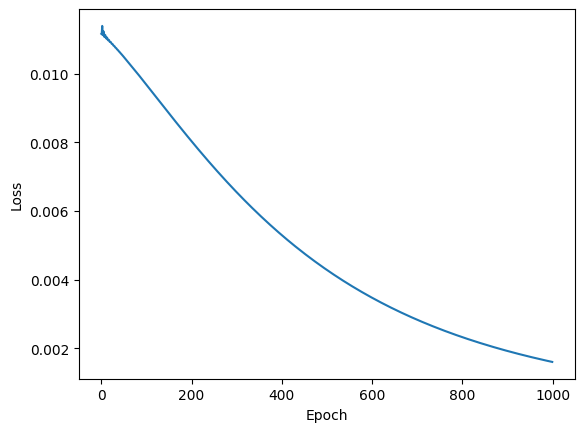

In [17]:
#split x,y
x = my_df.drop("species",axis=1).values #.values converts the stuff to numpy arrays
y = my_df["species"].values

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state = 41)# 0.2 ensures the split is like 20 % of the data is for testing and remaning for the training
# Convert x features to float tensors
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

# Convert y labels to long tensors
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

#Set the error function

criterion = nn.CrossEntropyLoss()# to use mse we must first convert the labels to one hot encoding first
#Choose gradient descent
optimzer = torch.optim.Adam(model.parameters(),lr=0.001)

#Train our model
epochs = 1000
losses = []
for i in range(epochs):
  #Go forward and get the prediction
  y_pred = model.forward(x_train)# Get the predicted results
  # Measure the loss
  loss = criterion(y_pred,y_train)
  # Record the loss
  losses.append(loss.item())
  print(f"Epoch: {i} and loss: {loss}")

  #Backpropogation
  optimzer.zero_grad()# zeros down previous weights so that they dont accumulate
  loss.backward()#Calculates the backpropogation stuff
  optimzer.step()#Performs the weight update with the optimizer

plt.plot(range(epochs),losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

Evaluate our model on the test set

In [19]:
with torch.no_grad():# basically we are preventing the backpropogation for test which the system will otherwise prepredict
  y_eval = model.forward(x_test)
  loss = criterion(y_eval,y_test)
print(loss)
accuracy_cnt=0
total_cnt=0
with torch.no_grad():
  y_eval = model.forward(x_test)
  for idx,i in enumerate(y_eval):
    if torch.argmax(i) == y_test[idx]:
      accuracy_cnt+=1
    total_cnt+=1
print((accuracy_cnt/total_cnt)*100)

tensor(0.7269)
93.33333333333333


Checking with some new input data

In [21]:
new_iris = torch.tensor([4.7,3.2,1.3,0.2])
with torch.no_grad():
  print(model(new_iris).argmax().item())



0


Saving and loading our neural network

In [24]:
#save
torch.save(model.state_dict(),'Iris_model')

#load
new_model= Model()
new_model.load_state_dict(torch.load('Iris_model'))


<All keys matched successfully>